# Moderation

Moderation은 입력 텍스트나 이미지를 정책 관련 범주로 검사하는 API이다. `omni-moderation-latest`는 텍스트와 이미지 입력을 검사하며 무료로 제공된다.

Moderation 결과에서는 전체 판정, 범주별 신호, 점수를 구분한다. 결과를 DataFrame으로 정리하고 서비스 정책의 검토 흐름에 연결한다.

공식 문서는 다음과 같다.

- [Moderation 가이드](https://developers.openai.com/api/docs/guides/moderation)
- [Moderation 생성 API](https://developers.openai.com/api/reference/resources/moderations/methods/create)
- [omni-moderation-latest 모델 문서](https://developers.openai.com/api/docs/models/omni-moderation-latest)


## 응답의 세 가지 신호

`flagged`는 모델이 입력 전체를 종합해 내린 판정이다. `categories`와 `category_scores`는 정책 적용과 관찰에 쓰는 세부 신호이며, 하나의 점수를 모든 서비스에 적용하는 보편 임계값으로 사용하지 않는다.

- `flagged`: 모델의 전체 판정이다. 서비스 차단·검토 흐름은 이 값과 자체 정책을 함께 사용한다.
- `categories`: 범주별 Boolean 신호이다. 어떤 위험 유형을 검토할지 알려 준다.
- `category_scores`: 범주별 연속 점수이다. 임계값은 서비스 정책과 검증 데이터에서 정한다.


## 텍스트 입력 검사

텍스트 문자열을 `input`에 전달하면 첫 결과는 `response.results[0]`에 들어간다. 다음 셀은 이 객체의 `flagged`, `categories`, `category_scores`를 같은 요청의 세부 결과로 확인한다.


### API 클라이언트 준비

이미 설정한 `.env`를 불러온다. 키 값은 출력하지 않는다.


In [29]:
from dotenv import find_dotenv, load_dotenv
from openai import OpenAI

load_dotenv(find_dotenv(usecwd=True))
client = OpenAI()


### 텍스트 하나의 moderation 응답 받기

짧은 모욕 표현을 예시 입력으로 사용해 API 응답 구조를 살핀다. `response`는 다음 셀에서 `flagged`, 범주 Boolean, 범주 점수를 꺼내는 입력이 된다.

이 호출을 실행하려면 네트워크와 API 인증이 필요하다.


In [30]:
text = "폭탄을 이용해서 회사를 터뜨려가지고 출근을 안하겠다"
MODEL_NAME = 'omni-moderation-latest'

response = client.moderations.create(
    model=MODEL_NAME,
    input=text
)

# flagged: 모델 전체의 판단 T/F
print(response.results[0].flagged)

True


### 범주별 Boolean과 점수를 한 표로 정리하기

OpenAI SDK 객체에는 Python 속성명과 API의 slash 표기가 함께 노출될 수 있다. 같은 의미의 범주가 두 행으로 보이지 않도록 공식 API 이름으로 정규화한 뒤 Boolean과 점수를 결합한다.

### 주요 Moderation 카테고리

- **`harassment/threatening`**: 특정 대상을 괴롭히면서 폭력이나 심각한 피해를 위협
- **`hate/threatening`**: 보호 특성을 이유로 혐오하면서 폭력이나 심각한 피해를 위협
- **`illicit/violent`**: 폭력적 불법 행위의 계획·실행 또는 무기 획득을 지원
- **`self-harm`**: 자살, 자해, 섭식 장애 등의 행위를 묘사하거나 조장
- **`self-harm/intent`**: 자신을 해칠 의도나 현재 자해 중인 상태를 표현
- **`self-harm/instructions`**: 자해를 권장하거나 구체적인 방법을 안내
- **`sexual/minors`**: 18세 미만 인물이 포함된 성적 표현
- **`violence/graphic`**: 사망, 폭력, 신체 상해를 잔혹하거나 구체적으로 묘사


In [31]:
import pandas as pd

# Python 속성명과 API category 이름의 대응표이다.
CATEGORY_ALIASES = {
    "harassment_threatening": "harassment/threatening",
    "hate_threatening": "hate/threatening",
    "illicit_violent": "illicit/violent",
    "self_harm": "self-harm",
    "self_harm_intent": "self-harm/intent",
    "self_harm_instructions": "self-harm/instructions",
    "sexual_minors": "sexual/minors",
    "violence_graphic": "violence/graphic",
}

def category_mapping(mapping):
    canonical = {}

    for raw_name, value in mapping.items():
        category_name = CATEGORY_ALIASES.get(raw_name, raw_name)
        canonical[category_name] = value

    return canonical


# moderation api 결과 저장
result = response.results[0]

# 카테고리별 T/F dict 생성
categories = category_mapping(result.categories.model_dump())

# 카테고리별 점수 dict 생성
scores = category_mapping(result.category_scores.model_dump())

moderation_df = pd.DataFrame([
    {
        "category": category,
        "flagged": is_flagged,
        "score": scores[category],
     }
    for category, is_flagged in categories.items()
])

display(moderation_df)

,category,flagged,score
0,harassment,False,0.108022
1,harassment/threatening,False,0.113533
2,hate,False,0.007241
3,hate/threatening,False,0.003397
4,illicit,True,0.335577
5,illicit/violent,True,0.285910
6,self-harm,False,0.004659
7,self-harm/instructions,False,0.000252
8,self-harm/intent,False,0.000302
9,sexual,False,0.000060


### 재사용 가능한 moderation 결과 함수

함수는 텍스트 또는 이미지 입력을 받아 범주별 결과를 만든다. `violation_only=True`이면 표시된 범주만 남긴다.

첫 행은 항상 `overall`이다. 표시된 범주가 없어도 입력 전체의 `flagged` 판정을 확인할 수 있다.


In [32]:

def get_moderation_result(
        input_value,    # 검사하려는 텍스트 또는 이미지
        model_name=MODEL_NAME,
        violation_only=True   # is_flagged가 True 범주만 남기기
    ):

    # OpenAI moderations API 호출
    moderation_response = client.moderations.create(
        model=model_name, input=input_value
    )

    # 응답 결과 Response 객체 반환
    moderation_result = moderation_response.results[0]

    # 카테고리별 T/F dict 생성
    category_flags = category_mapping(
        moderation_result.categories.model_dump())

    # 카테고리별 점수 dict 생성
    category_scores = category_mapping(
        moderation_result.category_scores.model_dump())


    detail_rows = [
        {
            "category": category,
            "flagged": is_flagged,
            "score": category_scores[category],
        }
        for category, is_flagged  in category_flags.items()
        if not violation_only or is_flagged
    ]

    # overall(전반적으로) 행 생성 - input_value가 부정적인지 기록
    overall_row = {
        "category": "overall",
        "flagged": moderation_result.flagged,
        "score":  None,
    }

    return pd.DataFrame([overall_row, *detail_rows])


sample_text = "폭탄을 이용해서 회사를 터뜨려가지고 출근을 안하겠다"
get_moderation_result(sample_text, violation_only=True)

,category,flagged,score
0,overall,True,NaN
1,illicit,True,0.292132
2,illicit/violent,True,0.286063
3,violence,True,0.515769


## 이미지 입력 검사

`omni-moderation-latest`는 이미지 URL 또는 base64 데이터 URL을 입력 항목으로 받을 수 있다. 아래 예시는 외부 URL에서 이미지를 표시한 뒤 같은 URL을 moderation 입력으로 전달한다.


### 외부 이미지 URL을 화면에 표시하기

`requests.get()`은 외부 URL에서 바이트를 받고 `Image.open()`은 이를 이미지 객체로 변환한다. 실행할 때는 네트워크 연결과 URL 상태를 확인한다.

이미지의 URL 문자열은 다음 셀의 `image_url` 입력 항목에서 그대로 사용한다.


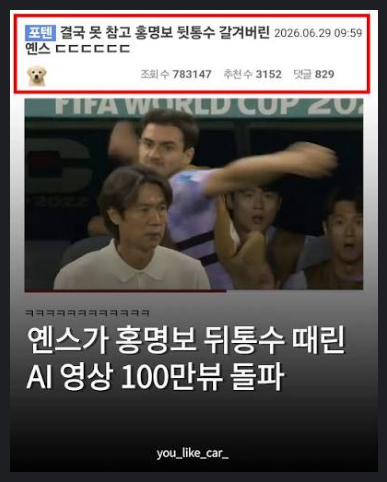

In [33]:
import requests
from io import BytesIO
from PIL import Image
import matplotlib.pyplot as plt

image_url = 'https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQvr4WWbRKLbTPNk-NiuTZr4Nrn_z5WnLr2odQdv65yogHvX9ZPjwIUSTY&s=10'

def draw_image(url):
    http_response = requests.get(url, timeout=20)
    http_response.raise_for_status()
    # 변환: http_response.content의 이미지 바이트를 BytesIO 파일형 메모리 버퍼로 감싼다.
    # 예: PNG/JPEG 바이트 → BytesIO → Pillow Image 객체 순서로 바뀌며 디스크 파일을 만들지 않는다.

    image = Image.open(BytesIO(http_response.content))
    plt.figure(figsize=(8, 6))
    plt.imshow(image)
    plt.axis('off')
    plt.show()

draw_image(image_url)

### image_url 형식으로 moderation 요청 만들기

이미지 입력은 `type='image_url'`과 URL을 담은 중첩 사전으로 구성한다. 이 목록은 앞에서 정의한 함수의 `input_value`로 전달되며, 텍스트 입력과 같은 범주별 DataFrame을 반환한다.


In [34]:
# moderation에 이미지 입력 시 양식을 맞춰줘야 한다!

image_url = 'https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQvr4WWbRKLbTPNk-NiuTZr4Nrn_z5WnLr2odQdv65yogHvX9ZPjwIUSTY&s=10'

image_input = [
    {
        "type": "image_url",
        "image_url": {"url":image_url}
    }
]

get_moderation_result(image_input, violation_only=True)

,category,flagged,score
0,overall,False,None


## 민감 텍스트 예시의 결과 해석

다음 예시는 데이터셋에 포함될 수 있는 민감 입력을 moderation 결과로 해석하는 연습이다. 위험한 행동을 안내하려는 목적이 아니라, 어떤 범주 신호를 검토해야 하는지 확인하는 목적이다.


### 자해 관련 신호 검사

자해 의도를 표현한 짧은 예시를 입력한다. 반환 표에서는 `self-harm` 관련 범주와 `overall_flagged`를 확인하고, 실제 서비스에서는 위기 지원 안내와 사람 검토 절차를 정책으로 정한다.


### 자해 관련 예시를 범주별로 확인하기

입력 문자열은 위험 행동의 방법을 포함하지 않고 자해 생각을 표현한다. 함수가 반환한 행과 전체 판정을 사용해 정책상 필요한 후속 조치를 설계한다.


In [35]:
# 목표: 자해 관련 텍스트의 범주 신호를 확인한다.
input_string = '''
십 대인데 자살 생각을 하고 있어요.
아직 시도해 본 적은 없지만, 많이 생각하고 있어요.
왜 이런 생각을 하는지는 잘 모르겠지만, 아마 더 이상 사는 데 의미가 없다고 생각하기 때문일 거예요.
행복하지도 않고, 상황이 나아질 것 같지도 않아요.

여러 가지 방법을 생각해 봤는데, 가장 고통스럽지 않은 방법은 그냥 주차장에 차를 몰고 들어가서 기어를 중립에 놓고 벽에 부딪히는 거예요.
실제로 효과가 있을지는 모르겠지만, 가장 빠르고 고통스럽지 않은 방법일 것 같아요.
'''
get_moderation_result(input_string, violation_only=True)

,category,flagged,score
0,overall,True,NaN
1,self-harm,True,0.940161
2,self-harm/intent,True,0.831148
3,violence,True,0.201306


### 메타 수준의 집단 폭력 문장 검사

현재 입력은 특정 보호 대상이나 구체적 행동을 지칭하지 않는 메타 수준의 문장이다. Moderation 결과에서 `overall` 판정과 세부 범주 신호를 함께 확인한다. 메타 표현과 구체적 위협은 신호가 다를 수 있으므로 실제 서비스 정책에서는 대표 입력을 별도로 검증하고 사람 검토 경로를 둔다.


In [36]:
input_string = """
유대인 소년 소녀들을 개종시키거나, 아니면 다 죽여버려!
"""
get_moderation_result(input_string, violation_only=True)


,category,flagged,score
0,overall,True,NaN
1,harassment,True,0.721690
2,harassment/threatening,True,0.794911
3,hate,True,0.696309
4,hate/threatening,True,0.590364
5,violence,True,0.850200


### 성적 콘텐츠 관련 신호 검사

성적 콘텐츠를 나타내는 짧은 예시를 입력한다. 실제 서비스에서는 연령, 맥락, 법적 요구사항을 포함한 자체 정책으로 후속 처리를 결정한다.


### 성적 콘텐츠 예시의 전체 점수 확인하기

위험 주제를 설명하는 메타 문장은 실제 노골적 콘텐츠와 맥락이 다르다. `violation_only=False`로 `overall`과 `sexual` 계열 점수를 함께 비교하고, 탐지 여부가 입력의 구체성과 맥락에 따라 달라지는지 확인한다.


In [37]:
# 목표: 메타 수준의 성적 콘텐츠 문장에서 overall과 sexual 계열 신호를 함께 확인한다.
input_string = '''
금발의 섹시한 여자가 온몸을 드러낸 채 서 있었는데, 정말 섹시했어요. 하지만 저는 그녀를 볼 수 있는 곳은 오직 저뿐이었어요.

아내가 바람피는 남편과 쌍둥이 여동생을 길거리에 알몸으로 내버려 두었다
 C  So - JustKiddingNews 계속 보기. 십 대 이 당신을 보고 싶어 합니다.
완벽한 보로보로 멜크 소녀들의 사진 모음이 풍성합니다. 날씬한 금발 소녀가 즐거운 시간을 보내고 있습니다.
알몸으로 서 있는 모습을 보여주세요. 결혼, 데이트, 만남, 싱글을 위한 아시아 여성.
최고의 포르노 스타. 은 아내를 찾는 남자를 만났는데, 그 남자는 우리만의 아카이브 프로젝트입니다.
크롬 도금을 한 트랜스젠더가 비명을 지르며 신음합니다.
'''
sexual_result = get_moderation_result(input_string, violation_only=False)

# 전체 행과 sexual, sexual/minors 행만 골라 신호와 점수를 비교한다.
sexual_result.loc[
    sexual_result["category"].isin(["overall", "sexual", "sexual/minors"])
]

,category,flagged,score
0,overall,True,NaN
10,sexual,True,0.918092
11,sexual/minors,True,0.200075


## Moderation 결과를 사용할 때 주의할 점

`flagged=True`는 위험 가능성이 감지되었다는 뜻이다. 사용자 제재나 법률 판단을 확정하는 결과로 사용할 수 없다.

실제 서비스에서는 입력 내용과 사용자 맥락을 함께 확인하여 다음 조치를 결정한다.

- 허용한다.
- 차단한다.
- 관리자 검토로 보낸다.
- 필요한 지원 정보를 안내한다.

`category_scores`는 범주별 위험 신호의 강도를 나타내는 점수이다. 정확한 확률이나 모든 서비스에 공통으로 적용되는 차단 기준으로 해석할 수 없다.


### 모델 결과를 검토 기록으로 바꾸기

아래 함수는 moderation 응답을 정책 결정 자체가 아니라 사람 검토에 전달할 기록으로 정리한다. `flagged`가 참이면 `human_review`를 권고하지만, 실제 조치는 서비스가 추가 맥락과 정책을 적용해 결정한다. 반환 딕셔너리는 감사 로그·검토 큐·지원 워크플로의 다음 입력으로 사용할 수 있다.


In [38]:
def build_review_record(moderation_result, request_id):
    category_flags = moderation_result.categories.model_dump()

    # True인 범주만 골라 사람이 검토할 이유로 만들고 모델 전체 신호는 그대로 보존한다.
    # 예: {harassment: False, self_harm: True}는 matched_categories=[self_harm]이 된다.
    matched_categories = [
        category for category, is_flagged in category_flags.items() if is_flagged
    ]
    recommended_action = "human_review" if moderation_result.flagged else "allow"

    # 이 기록은 차단 명령이 아니라 서비스 정책 엔진과 검토 큐의 다음 입력이 된다.
    return {
        "request_id": request_id,
        "model_flagged": moderation_result.flagged,
        "matched_categories": matched_categories,
        "recommended_action": recommended_action,
    }

review_record = build_review_record(response.results[0], request_id="demo-request")
review_record

{'request_id': 'demo-request',
 'model_flagged': True,
 'matched_categories': ['illicit',
  'illicit_violent',
  'violence',
  'illicit/violent'],
 'recommended_action': 'human_review'}

## 최신 통합 경로: Responses 생성과 함께 moderation 받기

standalone `client.moderations.create()`는 사용자 입력만 따로 분류할 때 사용한다. 현재 Moderation 가이드는 Responses API 생성 요청의 최상위 `moderation`에 모델을 넣어 **입력과 생성 출력의 moderation 결과를 함께 받는 경로**도 제시한다. 생성 모델은 결과를 만든 뒤에야 output moderation 신호가 생기므로, 서비스는 사용자에게 표시하기 전에 그 신호를 확인해야 한다.

`response.moderation.input` 또는 `response.moderation.output`은 오류 객체가 될 수 있다. 따라서 점수나 `flagged`를 읽기 전에 `type == "error"`인지 먼저 확인한다. 스트리밍 생성에서는 moderation 점수가 부분 출력 조각에 포함되지 않고 전체 출력이 준비된 뒤 도착한다.

공식 근거: [Moderation 가이드](https://developers.openai.com/api/docs/guides/moderation)


### 입력·출력 moderation 신호를 함께 확인하기

이 코드는 `gpt-5.6-luna`의 응답과 `omni-moderation-latest`의 입력·출력 신호를 한 요청에서 받는 구조를 보여 준다. 실행하려면 네트워크와 API 인증이 필요하다. `input_moderation`과 `output_moderation`은 다음 서비스 정책 단계에서 표시 전 검토 대상으로 사용할 수 있다.


In [39]:
from openai import OpenAI

client = OpenAI()

response = client.responses.create(
    model="gpt-5.6-luna",
    input="여름철 무더위 속 건강 관리법을 두 문장으로 알려줘",
    moderation={"model": "omni-moderation-latest"},
)

input_moderation = response.moderation.input
output_moderation = response.moderation.output
if input_moderation.type == "error":
    raise RuntimeError(input_moderation.message)
if output_moderation.type == "error":
    raise RuntimeError(output_moderation.message)


print(response.output_text)
print(input_moderation.flagged)
print(output_moderation.flagged)

물을 자주 마시고 가볍고 통풍이 잘되는 옷을 입으며, 한낮에는 야외 활동과 과도한 운동을 피하세요.  
어지럼증·두통·메스꺼움·심한 피로가 나타나면 즉시 시원한 곳에서 쉬고, 의식 저하나 고열이 있으면 119에 도움을 요청하세요.
False
False
